In [5]:
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
# import the pde solver for a simple 1-d tank of water with a drop of rain
import adv_dif_1D_bott_An
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar

In [154]:
importlib.reload(adv_dif_1D_bott_An)

L=20
T=60
n_grid = 77
n_time = 60
dx = L / (n_grid+3)
dt = T / n_time
x = np.arange(0,L+dx,dx) - 2*dx
t = np.arange(0,T+dt,dt)
c_ad,c_df,c_an_ad,c_an_df=adv_dif_1D_bott_An.adv_dif_1D([n_grid, n_time, L, T])

NameError: name 'c_now' is not defined

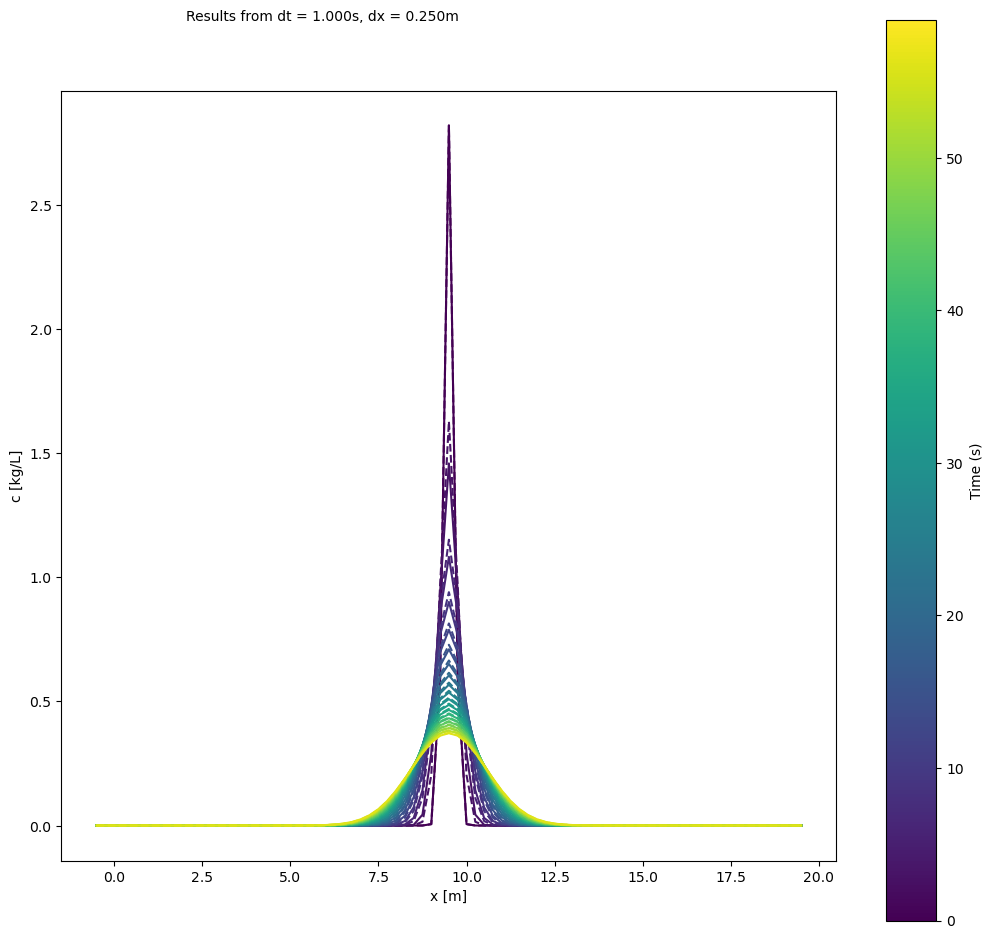

In [153]:
fig, ax_c = plt.subplots(1,1, figsize=(10,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fm' % (dt, dx))
ax_c.set_ylabel('c [kg/L]')
ax_c.set_xlabel('x [m]')

# We use color to differentiate lines at different times.  Set up the color map
cmap = plt.get_cmap('viridis')
cNorm  = colors.Normalize(vmin=0, vmax=1.*n_time)
cNorm_inseconds = colors.Normalize(vmin=0, vmax=1.*(n_time-1)*dt)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

# Only try to plot 20 lines, so choose an interval if more than that (i.e. plot every interval lines)
interval = int(np.ceil(n_time/20))

# Do the main plot
for time in range(0, n_time, interval):
    colorVal = scalarMap.to_rgba(time)
    ax_c.plot(x,c_ad[time, :], color=colorVal)
    #ax_c.plot(x,c_df[time, :], color=colorVal)
    #ax_c.plot(x,c_ad[time, :],'--', color=colorVal)
    ax_c.plot(x,c_df[time, :],'--', color=colorVal)

# Add the custom colorbar
ax_c = fig.add_axes([0.95, 0.05, 0.05, 0.9])
cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)
cb1.set_label('Time (s)')

In [139]:
x

array([-0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,
        6.25,  6.5 ,  6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,
        8.5 ,  8.75,  9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 ,
       10.75, 11.  , 11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75,
       13.  , 13.25, 13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75, 15.  ,
       15.25, 15.5 , 15.75, 16.  , 16.25, 16.5 , 16.75, 17.  , 17.25,
       17.5 , 17.75, 18.  , 18.25, 18.5 , 18.75, 19.  , 19.25, 19.5 ])

In [134]:
t

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60.])

In [124]:
np.shape(c)

(60, 81)